# Infer CNV on lung cancer dataset

In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter("ignore")

sc.settings.set_figure_params(figsize=(5, 5))

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_header()

Package,Version
scanpy,1.11.5
infercnvpy,0.6.1
matplotlib,3.10.7
Component,Info
Python,"3.11.0 | packaged by conda-forge | (main, Oct 25 2022, 06:24:40) [GCC 10.4.0]"
OS,Linux-5.14.0-503.22.1.el9_5.x86_64-x86_64-with-glibc2.34
CPU,"48 logical CPU cores, x86_64"
GPU,No GPU found
Updated,2026-03-04 02:01
Dependency,Version


## Loading the example dataset

In [3]:
adata = cnv.datasets.maynard2020_3k()
adata.var.loc[:, ["ensg", "chromosome", "start", "end"]].head()

100%|██████████| 49.5M/49.5M [00:00<00:00, 97.6MB/s]


,ensg,chromosome,start,end
symbol,,,,
AL645933.5,ENSG00000288587.1,chr6,31400702,31463705
AC010184.1,ENSG00000288585.1,chr3,141449745,141456434
AC023296.1,ENSG00000288580.1,chr8,2923568,2926689
AL117334.2,ENSG00000288577.1,chr20,3406380,3410036
AC107294.4,ENSG00000288576.1,chr3,184778723,184780720


Let's first inspect the UMAP plot based on the transcriptomics data:

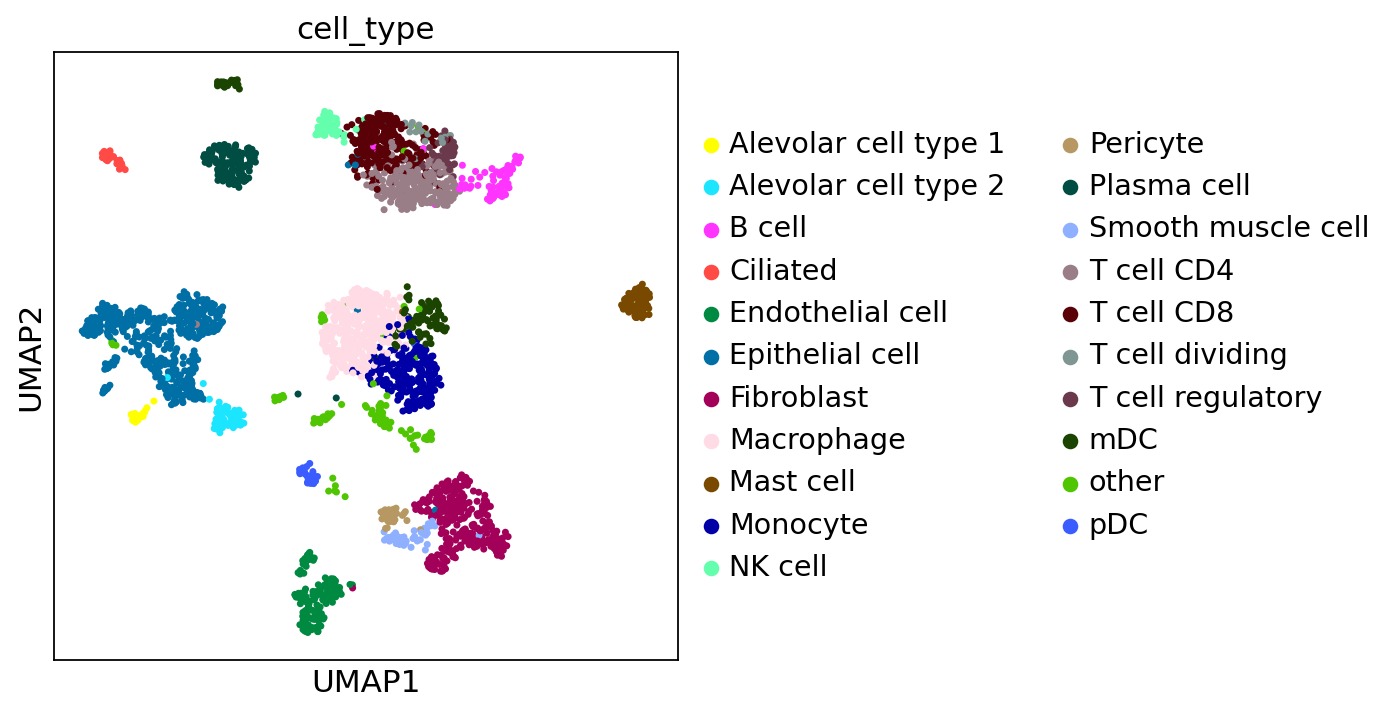

In [4]:
sc.pl.umap(adata, color="cell_type")

## Running infercnv

In [5]:
# We provide all immune cell types as "normal cells".
cnv.tl.infercnv(
    adata,
    reference_key="cell_type",
    reference_cat=[
        "B cell",
        "Macrophage",
        "Mast cell",
        "Monocyte",
        "NK cell",
        "Plasma cell",
        "T cell CD4",
        "T cell CD8",
        "T cell regulatory",
        "mDC",
        "pDC",
    ],
    window_size=250,
)

100%|██████████| 1/1 [00:19<00:00, 19.29s/it]


Now, we can plot smoothed gene expression by cell-type and chromosome. 
We can observe that the Epithelial cell cluster, which consists largely of tumor cells, appears
to be subject to copy number variation. 

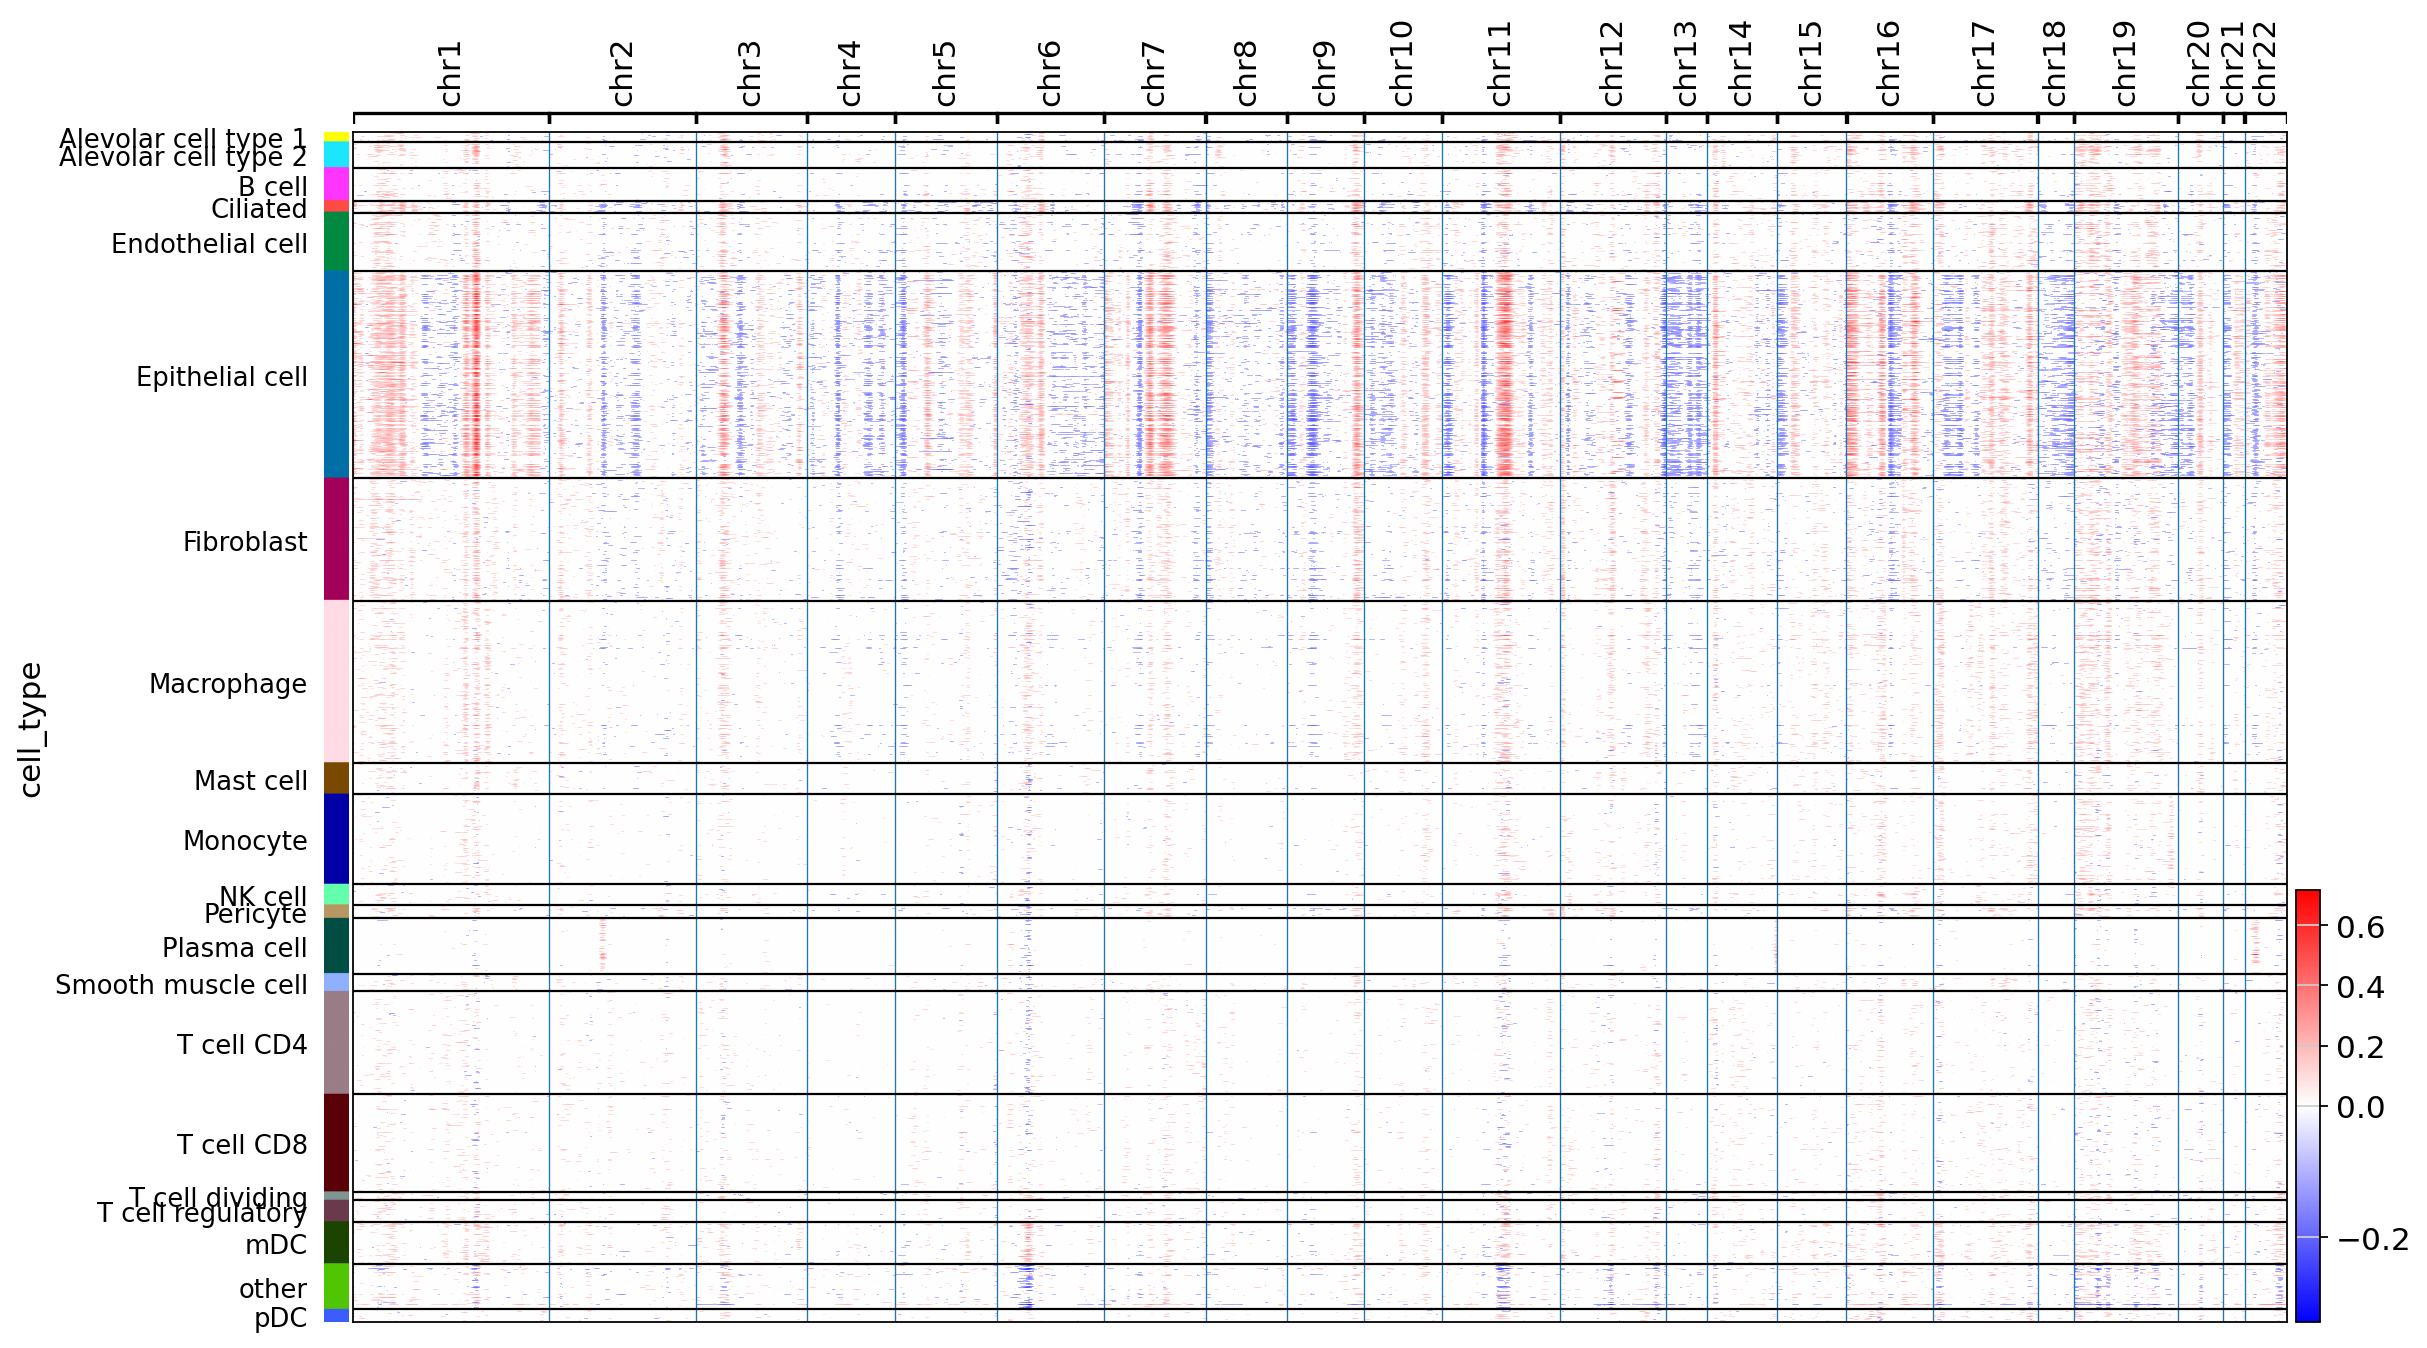

In [6]:
cnv.pl.chromosome_heatmap(adata, groupby="cell_type")

## Clustering by CNV profiles and identifying tumor cells

In [7]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)

2026-03-03 21:01:57.696948: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 21:01:57.746413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 21:01:59.032010: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 21:02:03.544908: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

After running leiden clustering, we can plot the chromosome heatmap 
by CNV clusters. We can observe that, as opposted to the clusters 
at the bottom, the clusters at the top have essentially no differentially expressed genomic regions. 
The differentially expressed regions are likely due to copy number variation and the respective 
clusters likely represent tumor cells. 

categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


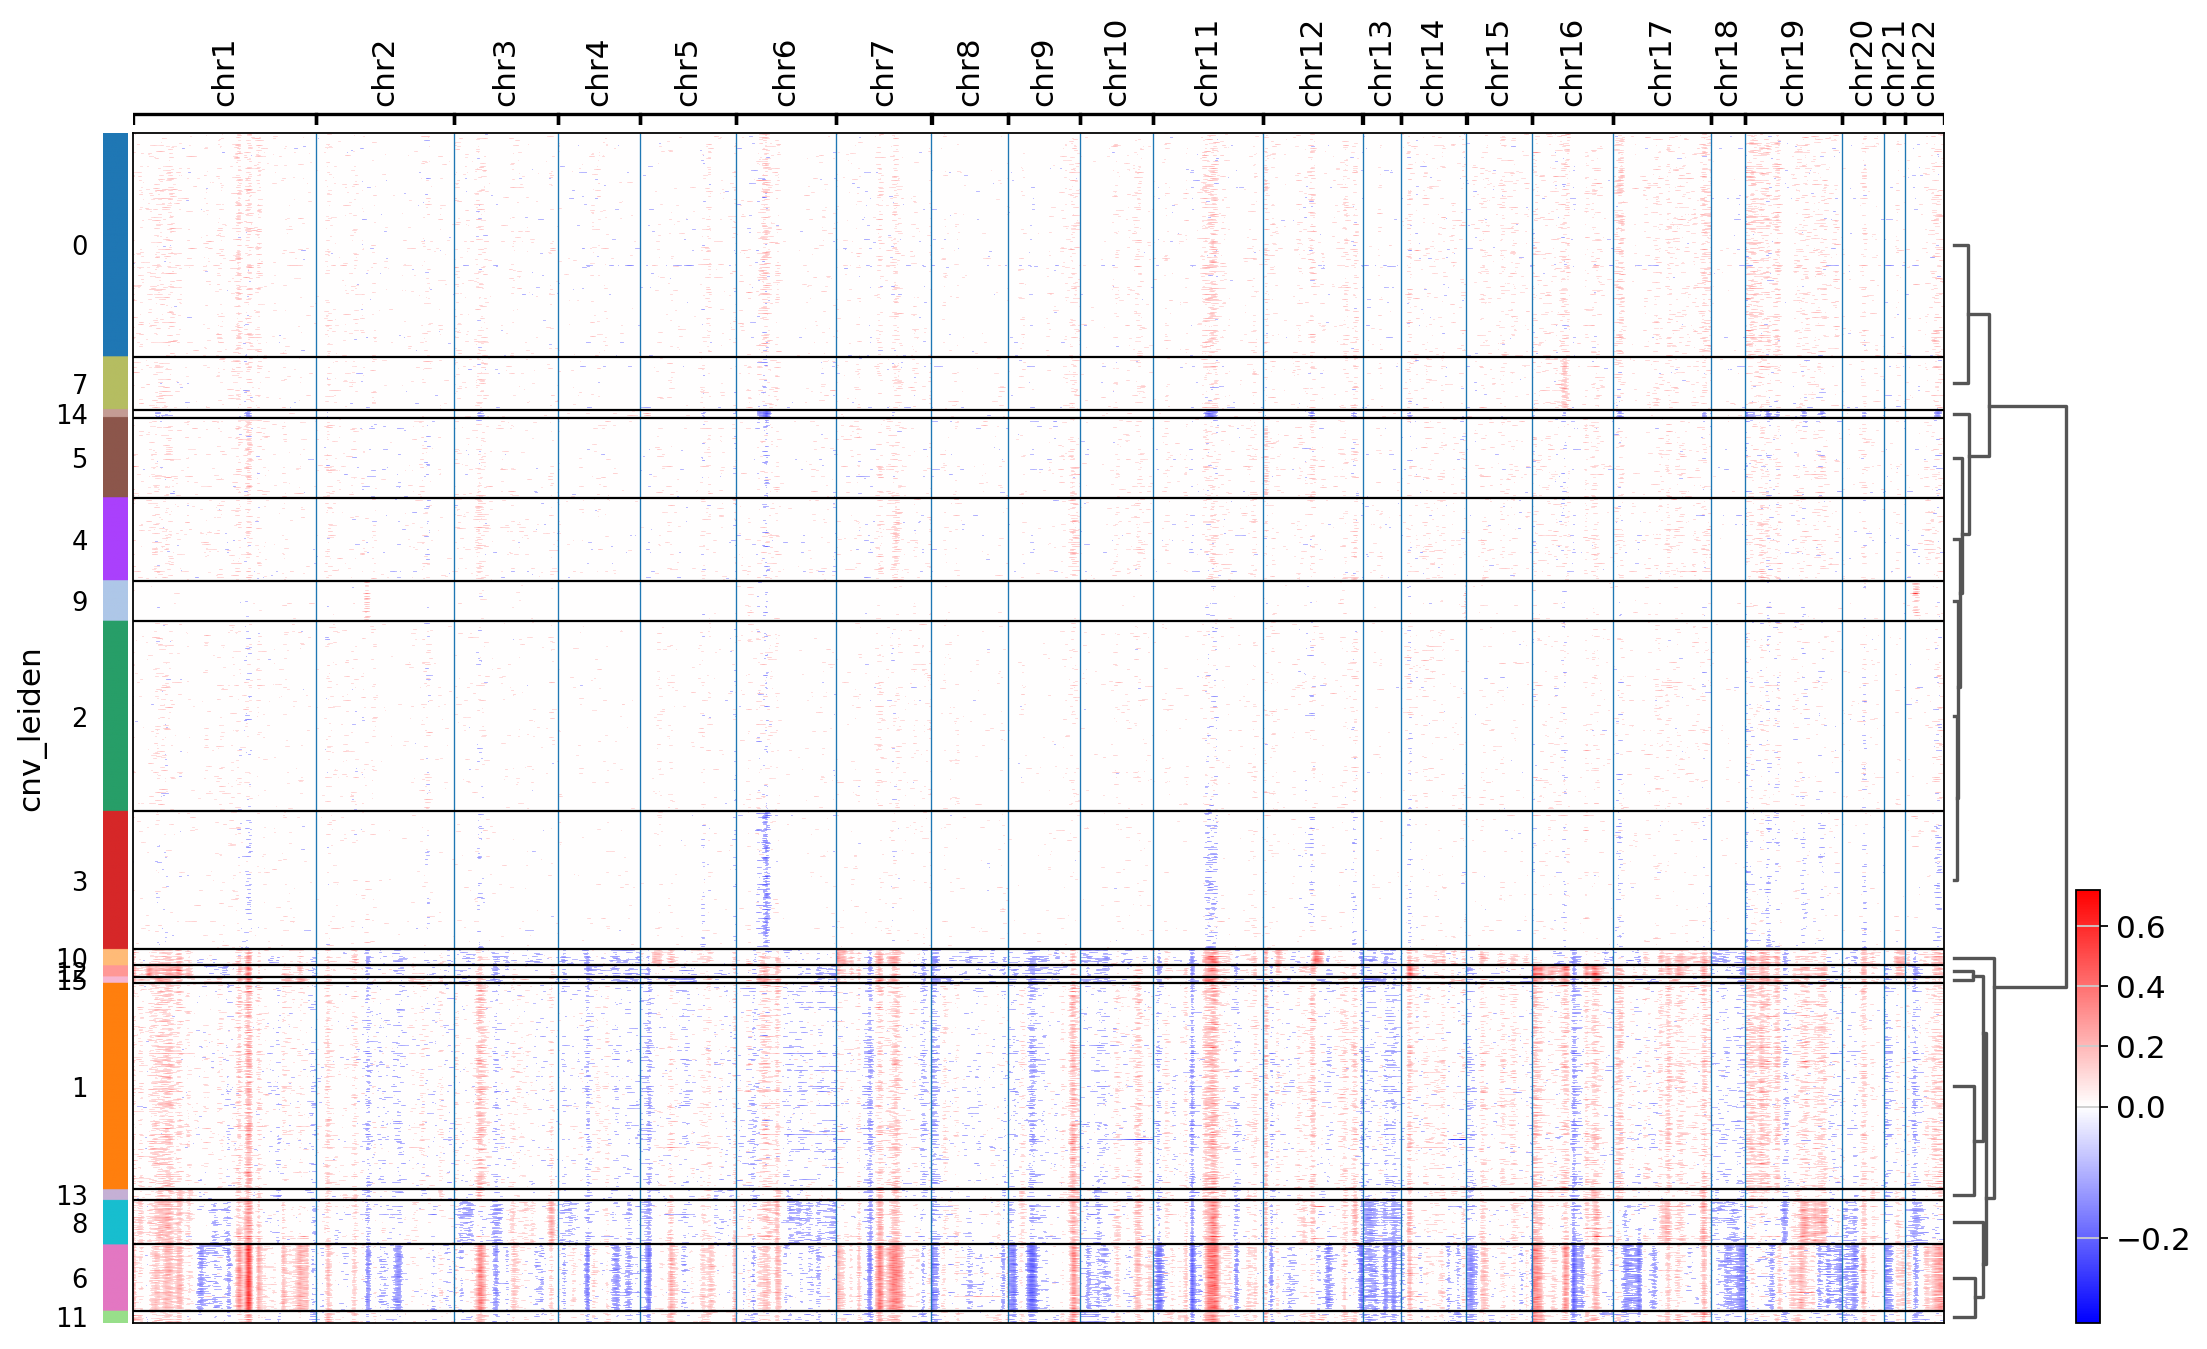

In [8]:
cnv.pl.chromosome_heatmap(adata, groupby="cnv_leiden", dendrogram=True)

### UMAP plot of CNV profiles

In [9]:
cnv.tl.umap(adata)
cnv.tl.cnv_score(adata)

The UMAP plot consists of a large blob of "normal" cells and several smaller clusters
with distinct CNV profiles. Except for cluster "12", which consists of ciliated cells, 
the isolated clusters are all epithelial cells. These are likely tumor cells and each 
cluster represents an individual sub-clone.

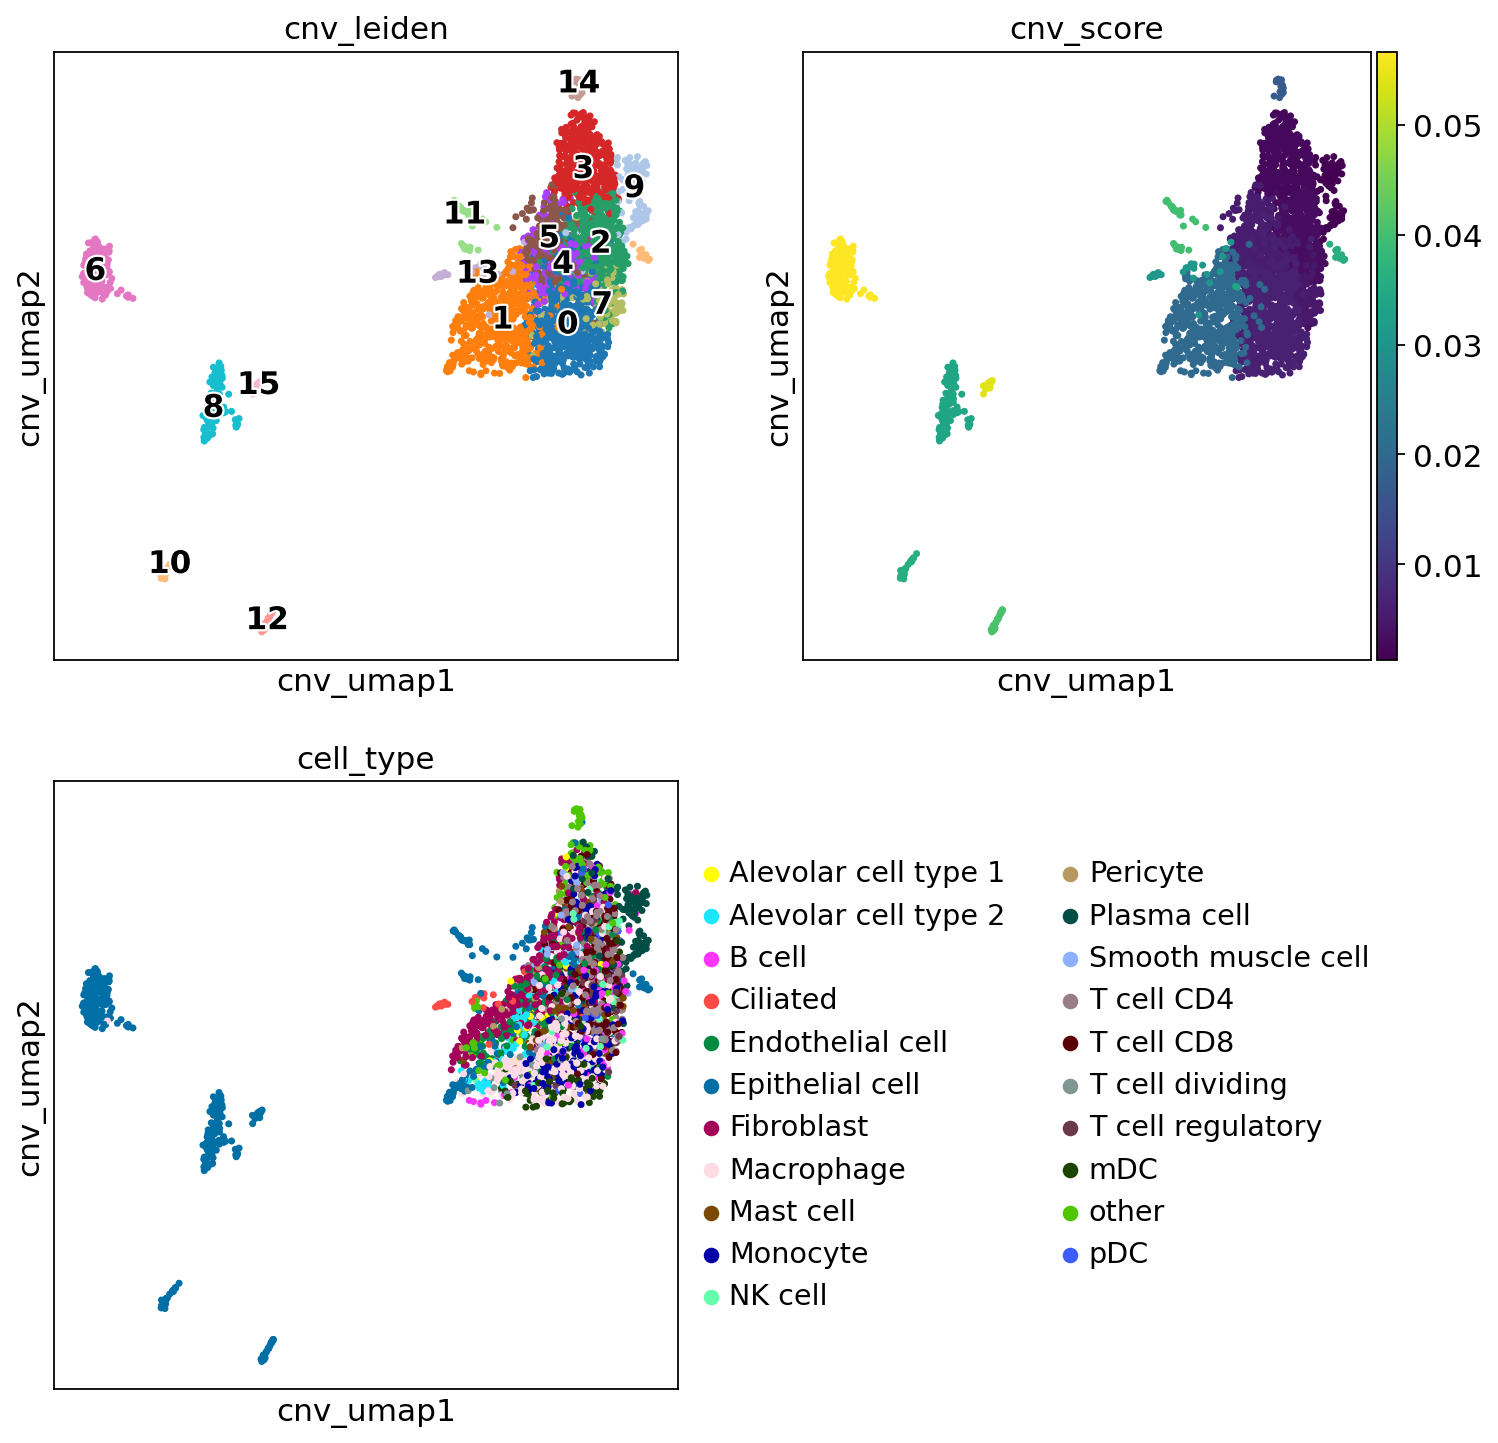

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="cell_type", ax=ax3)

We can also visualize the CNV score and clusters on the transcriptomics-based UMAP plot. 
Again, we can see that there are subclusters of epithelial cells that belong
to a distinct CNV cluster, and that these clusters tend to have the 
highest CNV score. 

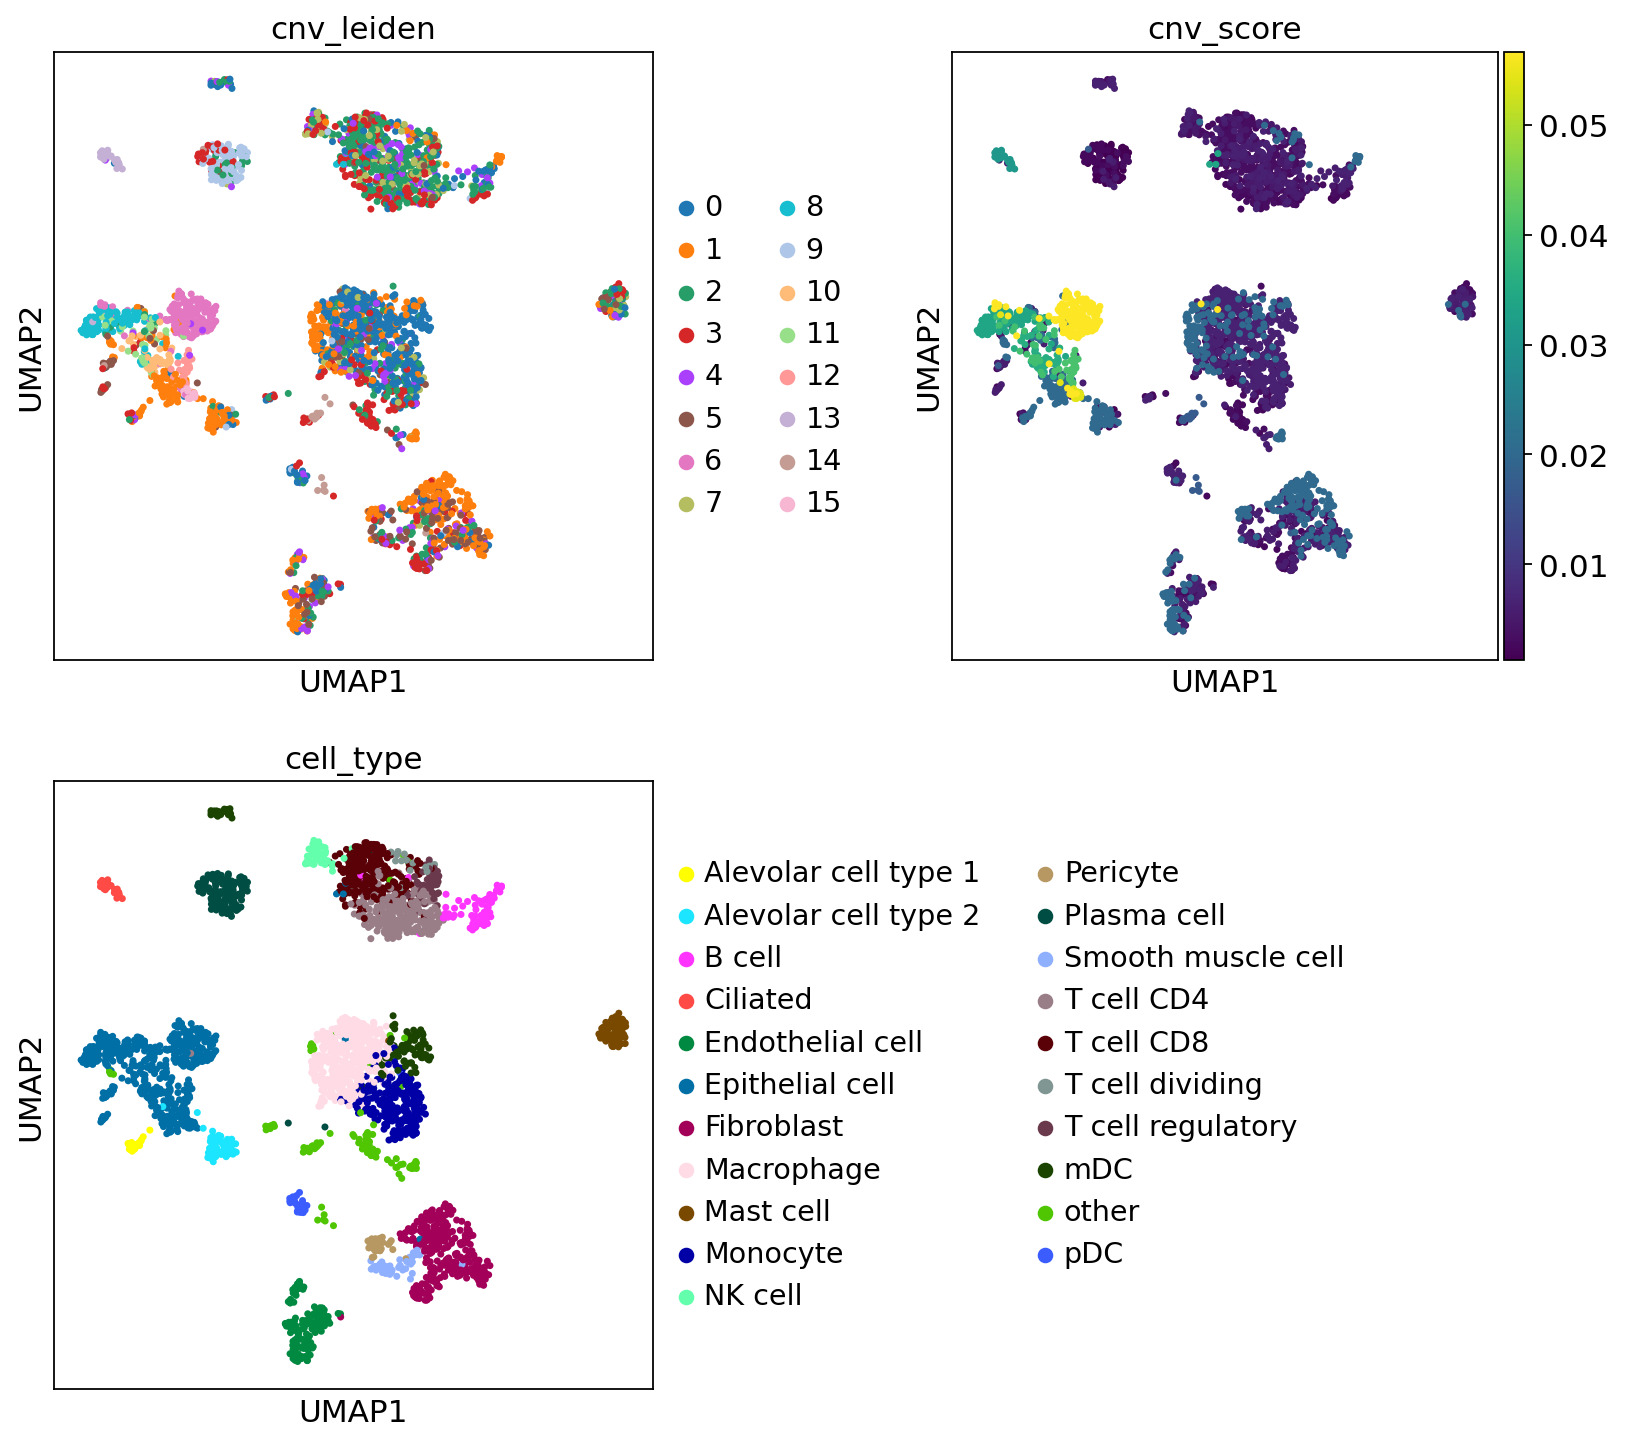

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 11), gridspec_kw={"wspace": 0.5})
ax4.axis("off")
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
sc.pl.umap(adata, color="cell_type", ax=ax3)

### Classifying tumor cells

Based on these observations, we can now assign cell to either "tumor" or "normal". 
To this end, we add a new column `cnv_status` to `adata.obs`. 

In [12]:
adata.obs["cnv_status"] = "normal"
adata.obs.loc[adata.obs["cnv_leiden"].isin(["10", "16", "13", "8", "12", "17", "1", "14", "11"]), "cnv_status"] = (
    "tumor"
)

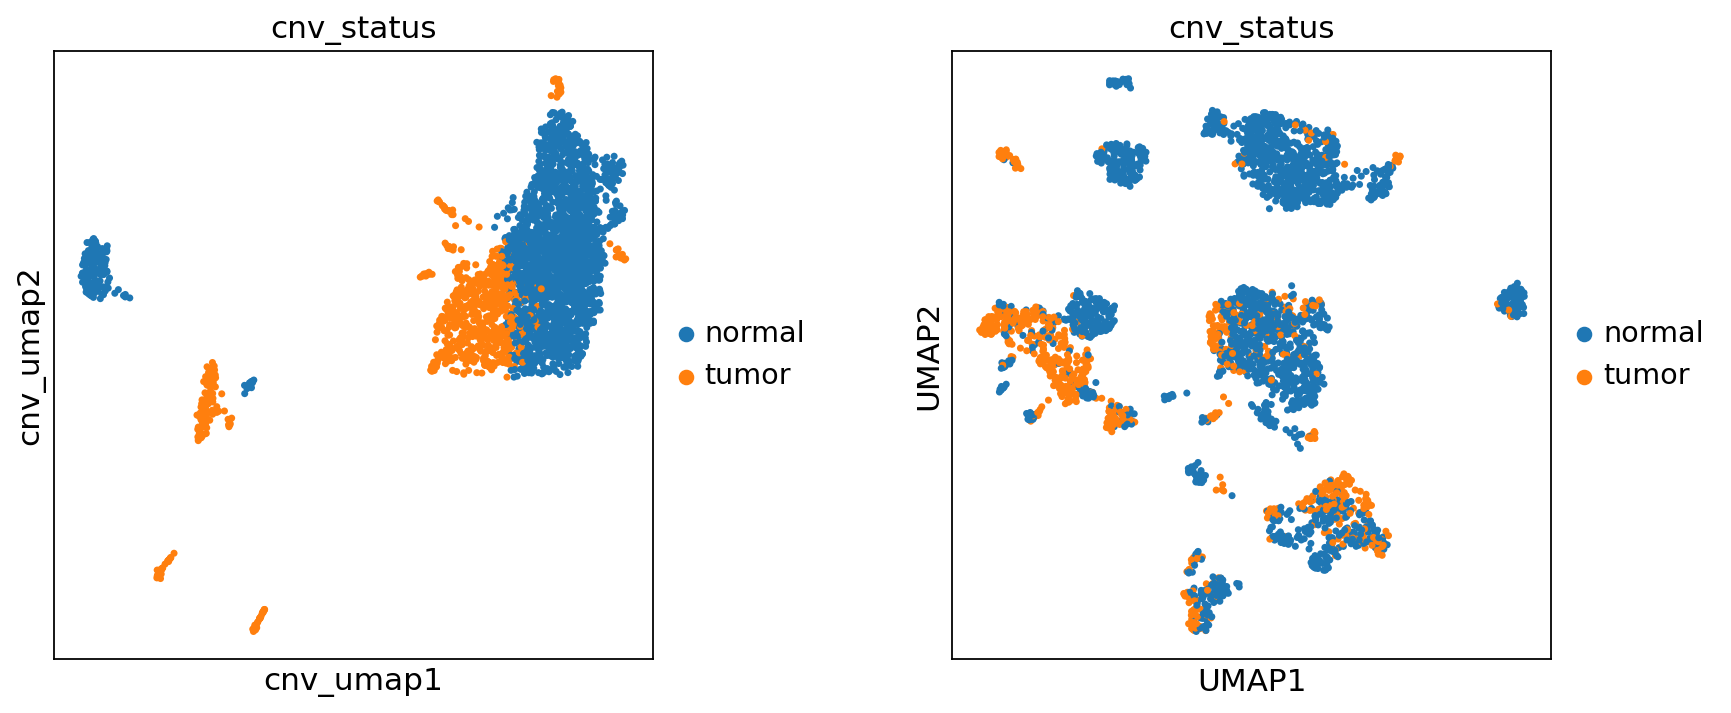

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.5})
cnv.pl.umap(adata, color="cnv_status", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_status", ax=ax2)

Now, we can plot the CNV heatmap for tumor and normal cells separately: 

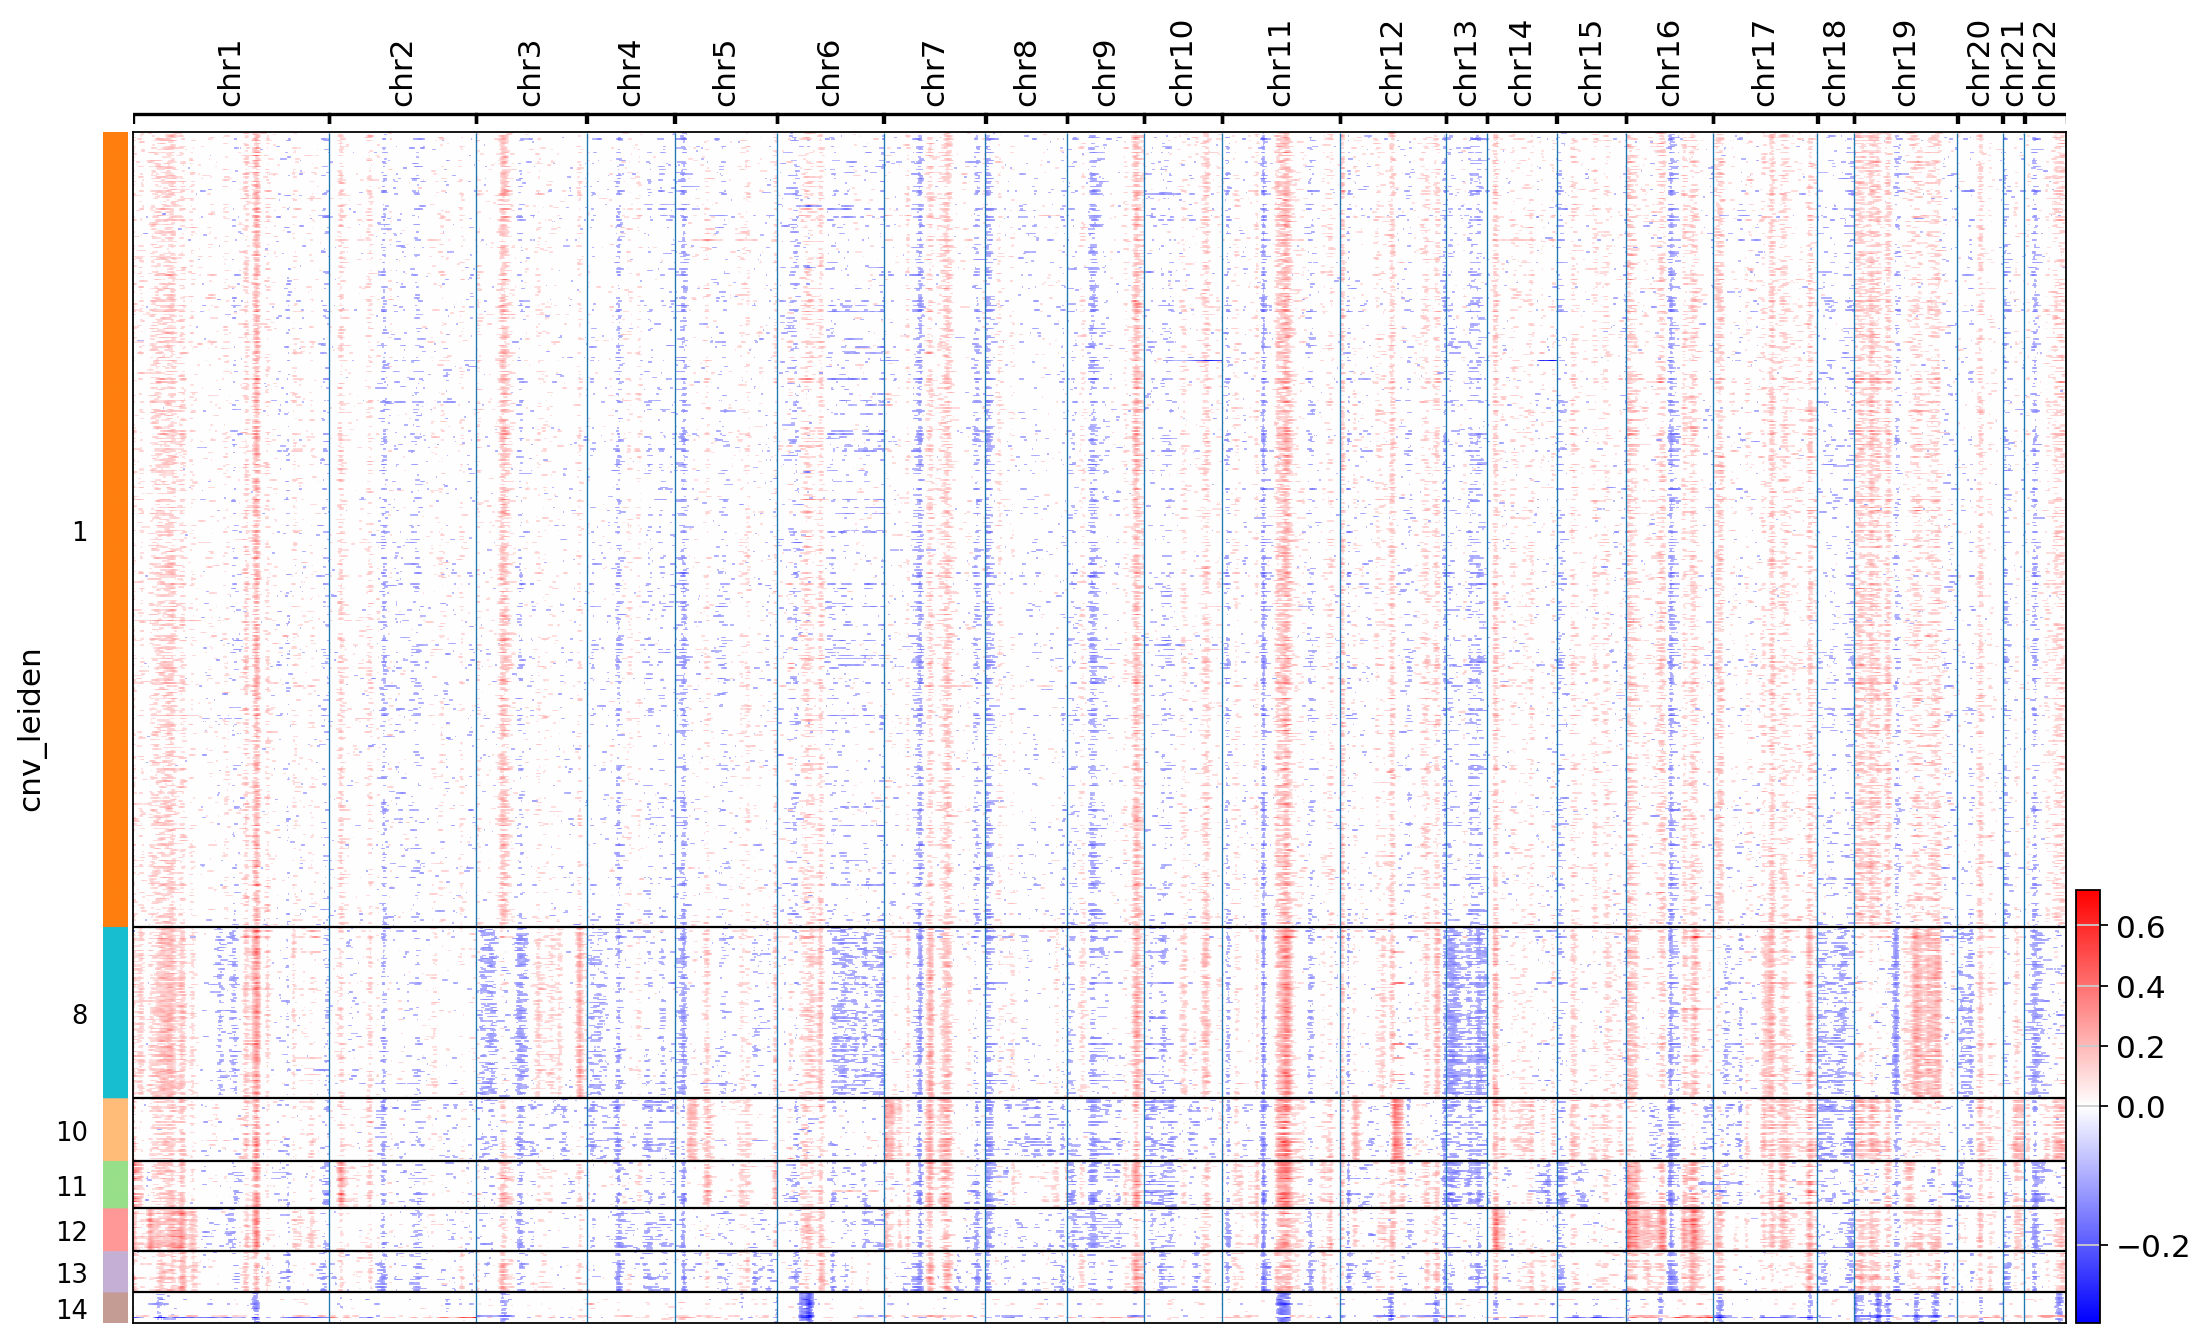

In [14]:
cnv.pl.chromosome_heatmap(adata[adata.obs["cnv_status"] == "tumor", :])

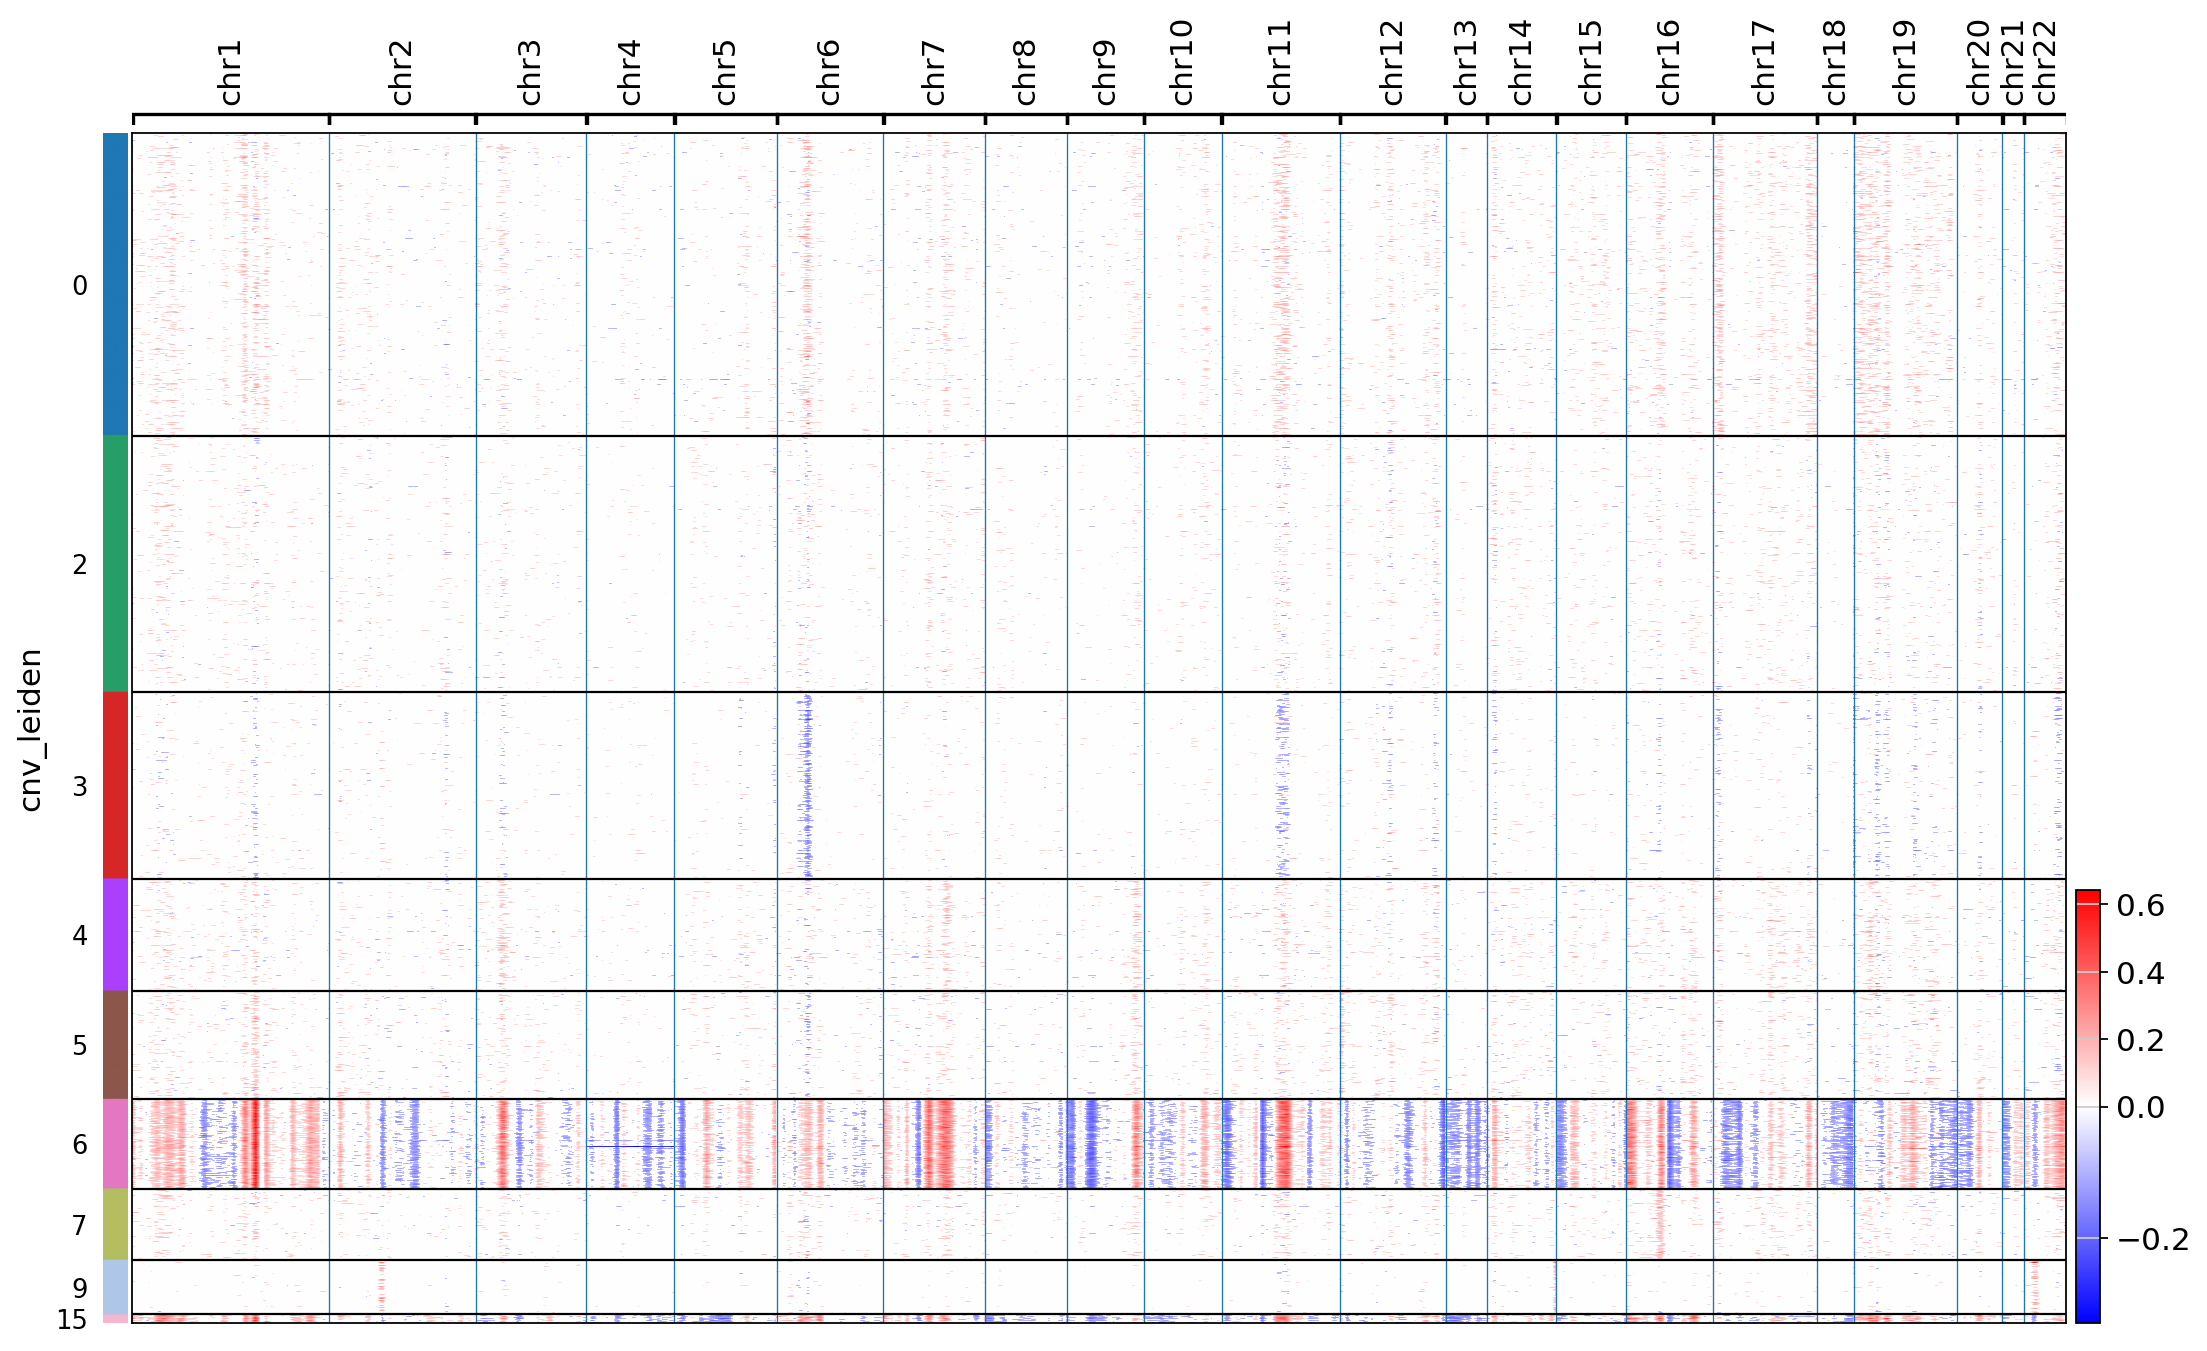

In [15]:
cnv.pl.chromosome_heatmap(adata[adata.obs["cnv_status"] == "normal", :])